# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

De soortelijke warmte $c$ van water is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram water met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa van het water in kilogram is en $\Delta T$ de verandering in temperatuur is.

$$
    Q = P*t
$$ (eq:heat)

Waarbij $P$ het vermogen in Watt en $t$ de tijd in seconden is.

Dus de formule voor het bepalen van de soortelijke warmte van water is:

$$
    c = \frac{P}{m*\frac{dT}{dt}}
$$ (eq:heat_capacity_of_water)



# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.

```
1. Vul de maatbeker met 400 ml water met behulp van een maatcilinder. plaats hierin het verwarmingselement.
2. Meet de starttemperatuur van het water en noteer deze.
3. Bouw de opstelling zoals is weergegeven op de afbeelding.
4. Gebruik een roerelement, zodat het water gelijkmatig opwarmt.
5. Stel de voeding zodanig in waarbij het vermogen zo dicht mogelijk, bij 40 Watt. Deze grens mag niet overschreden worden. Noteer I en U
6. Lees om de 30 seconden de temperatuur af van het water en noteer deze. 

## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.


# Resultaten


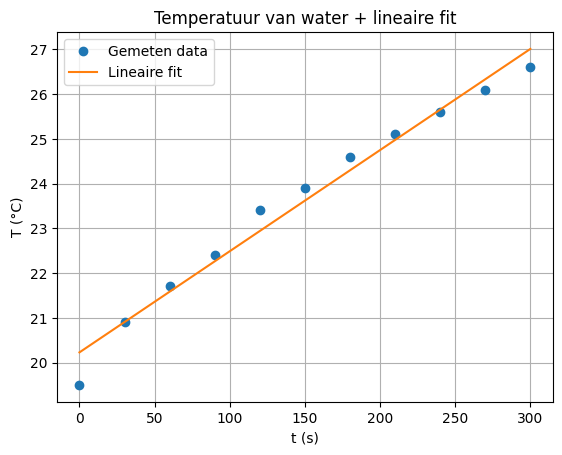

dT/dt uit fit = 0.022606060616597163 °C per seconde
Soortelijke warmte c = 4.321645970896675 kJ/(kg·°C)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Hier de data en de analyse
water = 0.4 #L
begin_temperatuur = 19.5 
spanning = 19.5 #V
stroom = 2 #A
time = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300]) #s
eind_temperatuur = np.array([19.5, 20.9, 21.7, 22.4, 23.4, 23.9, 24.6, 25.1, 25.6, 26.1, 26.6]) # graden Celsius
# eind_temperatuur berekend bij vaste spanning en stroom, ipv verschillende spanningen en stromen
P = spanning * stroom #W
 # graden Celsius
m = 0.4*0.998 #kg

def linear_model(t, a, b):
    return a * t + b

# --- 2. Fit uitvoeren ---
popt, pcov = curve_fit(linear_model, time, eind_temperatuur)
a, b = popt   # a = dT/dt, b = T(0)

c = P / (m * a) # Soortelijke warmte

t_fit = np.linspace(0, 300, 200)
T_fit = linear_model(t_fit, a, b)

plt.figure()
plt.plot(time, eind_temperatuur, 'o', label='Gemeten data')
plt.plot(t_fit, T_fit, '-', label='Lineaire fit')
plt.xlabel('t (s)')
plt.ylabel('T (°C)')
plt.title('Temperatuur van water + lineaire fit')
plt.grid()
plt.legend()
plt.show()

print("dT/dt uit fit =", a, "°C per seconde")
print("Soortelijke warmte c =", c/1000, "kJ/(kg·°C)")


In [ ]:
# Sla figuren op met  
# 
# plt.savefig("figures/naam.png", dpi=450)



# Discussie en conclusie

Hier een korte discussie en conclusie over de resultaten van het experiment en de implicaties daarvan.